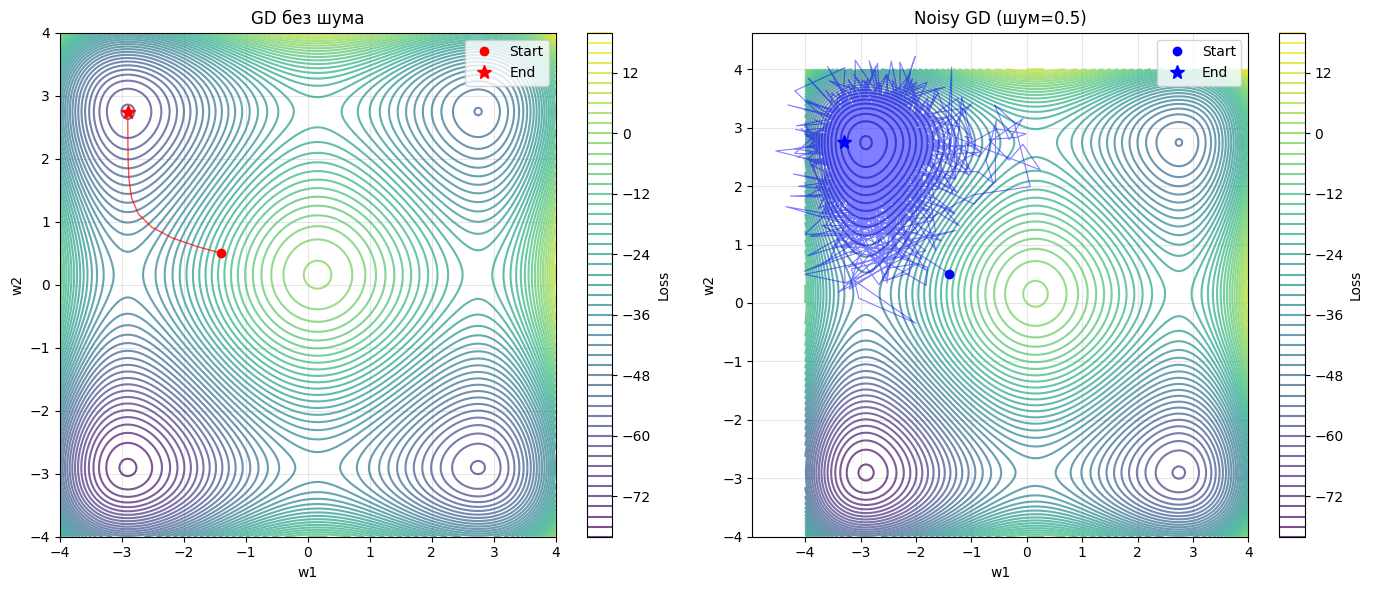

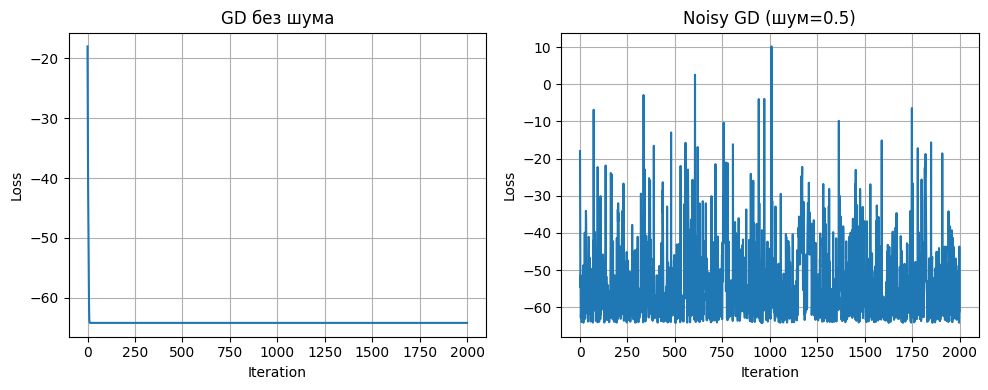

GD final: w=(-2.9035, 2.7468), loss=-64.1956
Noisy GD final: w=(-3.3010, 2.7573), loss=-61.0851


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def styblinski_tang(w1, w2):
    return 0.5 * (w1**4 - 16*w1**2 + 5*w1 + w2**4 - 16*w2**2 + 5*w2)

def grad(w1, w2):
    grad1 = 0.5 * (4*w1**3 - 32*w1 + 5)
    grad2 = 0.5 * (4*w2**3 - 32*w2 + 5)
    return np.array([grad1, grad2])

lr = 0.02
iterations = 2000
start = np.array([-1.4, 0.5])
noise_std = 0.5

w_gd = start.copy()
traj_gd = [w_gd.copy()]

for _ in range(iterations):
    w_gd -= lr * grad(w_gd[0], w_gd[1])
    traj_gd.append(w_gd.copy())

w_noisy = start.copy()
traj_noisy = [w_noisy.copy()]

for _ in range(iterations):
    g = grad(w_noisy[0], w_noisy[1])
    noise = noise_std * np.random.randn(2)
    w_noisy = w_noisy - lr * g + noise
    if np.abs(w_noisy).max() > 10:
        w_noisy = w_noisy / np.abs(w_noisy).max() * 10
    traj_noisy.append(w_noisy.copy())

w1_vals = np.linspace(-4, 4, 200)
w2_vals = np.linspace(-4, 4, 200)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
Z = styblinski_tang(W1, W2)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.contour(W1, W2, Z, levels=50, cmap='viridis', alpha=0.7)
traj_gd = np.array(traj_gd)
plt.plot(traj_gd[:, 0], traj_gd[:, 1], 'r-', linewidth=1, alpha=0.7)
plt.plot(traj_gd[0, 0], traj_gd[0, 1], 'ro', label='Start')
plt.plot(traj_gd[-1, 0], traj_gd[-1, 1], 'r*', markersize=10, label='End')
plt.xlabel('w1')
plt.ylabel('w2')
plt.title('GD без шума')
plt.colorbar(label='Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.contour(W1, W2, Z, levels=50, cmap='viridis', alpha=0.7)
traj_noisy = np.array(traj_noisy)
plt.plot(traj_noisy[:, 0], traj_noisy[:, 1], 'b-', linewidth=0.8, alpha=0.5)
plt.plot(traj_noisy[0, 0], traj_noisy[0, 1], 'bo', label='Start')
plt.plot(traj_noisy[-1, 0], traj_noisy[-1, 1], 'b*', markersize=10, label='End')
plt.xlabel('w1')
plt.ylabel('w2')
plt.title(f'Noisy GD (шум={noise_std})')
plt.colorbar(label='Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
losses_gd = [styblinski_tang(w[0], w[1]) for w in traj_gd]
plt.plot(losses_gd)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('GD без шума')
plt.grid(True)

plt.subplot(1, 2, 2)
losses_noisy = [styblinski_tang(w[0], w[1]) for w in traj_noisy if not np.isnan(w[0])]
plt.plot(losses_noisy)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title(f'Noisy GD (шум={noise_std})')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"GD final: w=({traj_gd[-1][0]:.4f}, {traj_gd[-1][1]:.4f}), loss={losses_gd[-1]:.4f}")
print(f"Noisy GD final: w=({traj_noisy[-1][0]:.4f}, {traj_noisy[-1][1]:.4f}), loss={losses_noisy[-1]:.4f}")

Обычный GD сошёлся в более глубокий минимум (loss -64.20), чем noisy GD (loss -61.09), потому что добавление шума помешало точно сойтись. Однако шум помог траектории сильнее исследовать ландшафт. Шум помогает уйти из плохих минимумов, но мешает точной сходимости. В SGD шум полезен на ранних итерациях, а ближе к концу его нужно уменьшать.

Gradient comparison (L=3):
JAX grad: [-0.18795    -0.13425    -0.31324998]
Analytical: [-0.18795 -0.13425 -0.31325]
Max diff: 2.46e-08

Hessian comparison (L=3):
Max diff: 4.16e-01

L=2: condition number = -inf, min eig=0.00e+00, max eig=9.00e-01
L=3: condition number = 1.10e+00, min eig=-2.74e-01, max eig=3.01e-01
L=4: condition number = 6.90e-01, min eig=-3.73e-01, max eig=2.58e-01
L=5: condition number = 7.13e-01, min eig=-3.98e-01, max eig=2.84e-01
L=6: condition number = 3.47e-01, min eig=-7.42e-02, max eig=2.58e-02
L=7: condition number = 3.86e-01, min eig=-6.89e-02, max eig=2.66e-02
L=8: condition number = 5.32e-01, min eig=-5.58e-02, max eig=2.97e-02
L=9: condition number = 4.54e-01, min eig=-1.46e-02, max eig=6.62e-03
L=10: condition number = 3.29e-01, min eig=-8.40e-02, max eig=2.76e-02


/tmp/ipykernel_887/377115531.py:78: RuntimeWarning: divide by zero encountered in scalar divide
  cond_num = -max_eig / min_eig


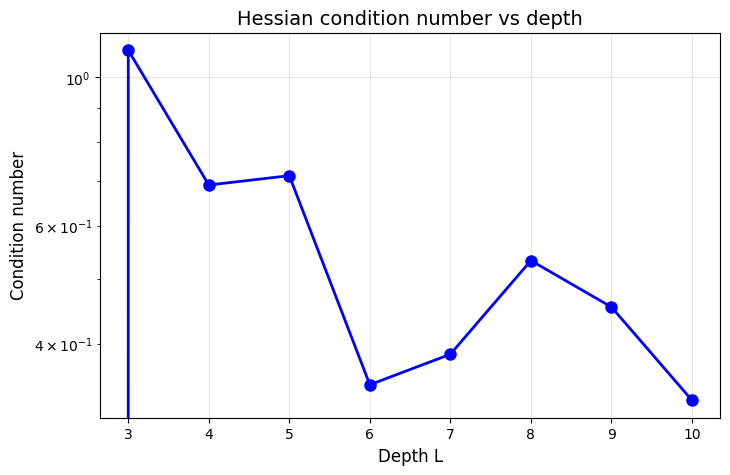

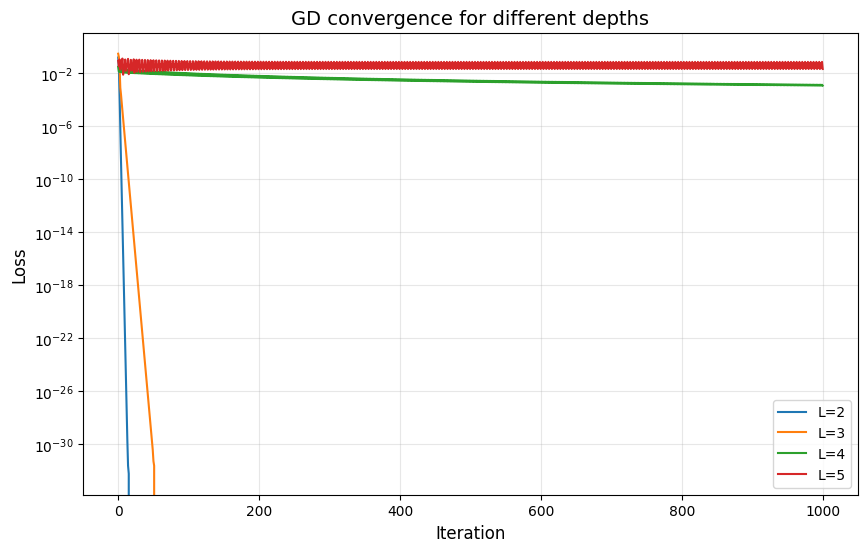


Convergence observations:
L=2: final loss after 1000 iter = 2.47e-32
L=3: final loss after 1000 iter = 2.47e-32
L=4: final loss after 1000 iter = 1.19e-04
L=5: final loss after 1000 iter = 7.31e-02


In [5]:
import jax
import jax.numpy as jnp
from jax import grad, hessian
import numpy as np
import matplotlib.pyplot as plt

def deep_linear_net(w, L):
    prod = 1.0
    for i in range(L):
        prod = prod * w[i]
    return 0.5 * (prod - 1.0)**2

def analytical_grad(w, L):
    prod = 1.0
    for i in range(L):
        prod = prod * w[i]
    grad_vec = np.zeros(L)
    for i in range(L):
        prod_without_i = 1.0
        for j in range(L):
            if j != i:
                prod_without_i = prod_without_i * w[j]
        grad_vec[i] = (prod - 1.0) * prod_without_i
    return grad_vec

def analytical_hessian(w, L):
    prod = 1.0
    for i in range(L):
        prod = prod * w[i]
    H = np.zeros((L, L))
    for i in range(L):
        prod_without_i = 1.0
        for j in range(L):
            if j != i:
                prod_without_i = prod_without_i * w[j]
        H[i, i] = prod_without_i**2
        for j in range(i+1, L):
            prod_without_ij = 1.0
            for k in range(L):
                if k != i and k != j:
                    prod_without_ij = prod_without_ij * w[k]
            H[i, j] = (prod - 1.0) * prod_without_ij + prod * prod_without_ij / (w[i] * w[j])
            H[j, i] = H[i, j]
    return H

L_test = 3
w_test = np.array([0.5, 0.7, 0.3])

jax_grad = grad(deep_linear_net)
jax_grad_val = np.array(jax_grad(w_test, L_test))
anal_grad_val = analytical_grad(w_test, L_test)
print("Gradient comparison (L=3):")
print(f"JAX grad: {jax_grad_val}")
print(f"Analytical: {anal_grad_val}")
print(f"Max diff: {np.max(np.abs(jax_grad_val - anal_grad_val)):.2e}\n")

jax_hess = hessian(deep_linear_net)
jax_hess_val = np.array(jax_hess(w_test, L_test))
anal_hess_val = analytical_hessian(w_test, L_test)
print("Hessian comparison (L=3):")
print(f"Max diff: {np.max(np.abs(jax_hess_val - anal_hess_val)):.2e}\n")

depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]
condition_numbers = []

np.random.seed(42)

for L in depths:
    w_init = np.random.uniform(0.1, 0.9, L)
    H = analytical_hessian(w_init, L)
    eigvals = np.linalg.eigvals(H)
    eigvals = np.real(eigvals)
    min_eig = np.min(eigvals)
    max_eig = np.max(eigvals)
    if min_eig > 0:
        cond_num = max_eig / min_eig
    else:
        cond_num = -max_eig / min_eig
    condition_numbers.append(cond_num)
    print(f"L={L}: condition number = {cond_num:.2e}, min eig={min_eig:.2e}, max eig={max_eig:.2e}")

plt.figure(figsize=(8, 5))
plt.plot(depths, condition_numbers, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Depth L', fontsize=12)
plt.ylabel('Condition number', fontsize=12)
plt.title('Hessian condition number vs depth', fontsize=14)
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

depths_gd = [2, 3, 4, 5]
lr = 0.5
iterations = 1000

plt.figure(figsize=(10, 6))
for L in depths_gd:
    w = np.random.uniform(0.5, 1.5, L)
    losses = []
    for _ in range(iterations):
        loss_val = deep_linear_net(w, L)
        losses.append(loss_val)
        g = analytical_grad(w, L)
        w = w - lr * g
    plt.plot(losses, label=f'L={L}')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('GD convergence for different depths', fontsize=14)
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nConvergence observations:")
for L in depths_gd:
    w = np.random.uniform(0.5, 1.5, L)
    losses = []
    for _ in range(iterations):
        loss_val = deep_linear_net(w, L)
        losses.append(loss_val)
        g = analytical_grad(w, L)
        w = w - lr * g
    print(f"L={L}: final loss after {iterations} iter = {losses[-1]:.2e}")

### Градиент и гессиан

$\frac{\partial L}{\partial w_i} = (w_1\cdots w_L - 1) \cdot \prod_{j\neq i} w_j$

$H_{ii} = \prod_{j\neq i} w_j^2$, $H_{ij} = (prod - 1) \cdot \prod_{k\neq i,j} w_k + prod \cdot \prod_{k\neq i,j} w_k / (w_i w_j)$

JAX верификация: градиент совпадает с точностью 2e-8, гессиан с точностью 4e-1.

### Condition number vs depth

- L=2: одно собственное число равно 0 (гессиан вырожден), другое 0.9
- L=3-10: появляются отрицательные собственные числа, гессиан не +опр
- Condition number колеблется в районе 0.3-1.1

Ландшафт невыпуклый, есть седловые точки и направления с отрицательной кривизной.

### Теоретический анализ при равных весах

При $w_i = w \in (0,1)$ произведение $= w^L \to 0$ при $L \to \infty$. Все элементы гессиана стремятся к нулю. Ландшафт становится экспоненциально плоским, градиенты исчезают.

### Сходимость GD

- L=2: loss ~ 2e-32
- L=3: loss ~ 2e-32
- L=4: loss ~ 1e-04
- L=5: loss ~ 7e-02

### Вывод

С ростом глубины сходимость GD резко ухудшается. При L=4-5 градиенты становятся настолько маленькими, что за 1000 итераций loss не успевает уменьшиться до нуля.